# PRAKTIKUM PENAMBANGAN DATA (PPD)
## MODUL 2: EXPLORATORY DATA ANALYSIS DAN DATA PREPROCESSING

* **Nama**: Januarsyah
* **Mata Kuliah**: Praktikum Penambangan Data (SVPL214610)
* **Program Studi**: D4 Teknologi Rekayasa Perangkat Lunak, Sekolah Vokasi UGM

---


### Environment Setup
Inisialisasi pustaka utama (`pandas`, `numpy`, `matplotlib`, `scikit-learn`) dan cek versi.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

print(f"NumPy Version      : {np.__version__}")
print(f"Pandas Version     : {pd.__version__}")
print(f"Matplotlib Version : {plt.matplotlib.__version__}")


NumPy Version      : 2.1.3
Pandas Version     : 2.2.3
Matplotlib Version : 3.10.0


---
# 1. LANGKAH PERCOBAAN: EXPLORATORY DATA ANALYSIS (EDA)

EDA adalah proses menggali informasi awal dari dataset: distribusi, korelasi, outlier, missing values, dan duplikasi. Dataset utama: **BankChurners** (credit card customers).


#### 1.1 Impor Pustaka


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


#### 1.2 Load Dataset
Sumber: [Credit Card Customers (Kaggle)](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)


In [3]:
df_churning = pd.read_csv(
    'https://raw.githubusercontent.com/ganjar87/data_science_practice/main/BankChurners.csv',
    delimiter=','
)
print('Shape:', df_churning.shape)
print('Kolom:', list(df_churning.columns))


Shape: (10127, 21)
Kolom: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


#### 1.3 Lima Baris Pertama (`df.head()`)


In [4]:
df_churning.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


#### 1.4 Lima Baris Terakhir (`df.tail()`)


In [5]:
df_churning.tail()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189


#### 1.5 Pisah Dataset berdasarkan Class
Kolom `Attrition_Flag` jadi dua subset: nasabah aktif vs nasabah churn.


In [6]:
existing_data = df_churning[(df_churning.Attrition_Flag == 'Existing Customer')]
attrited_data = df_churning[(df_churning.Attrition_Flag == 'Attrited Customer')]

print('Existing :', existing_data.shape)
print('Attrited :', attrited_data.shape)


Existing : (8500, 21)
Attrited : (1627, 21)


#### 1.6 Line Chart
Dummy dulu, lalu time series sensor IoT (`Humidity` vs `date`).


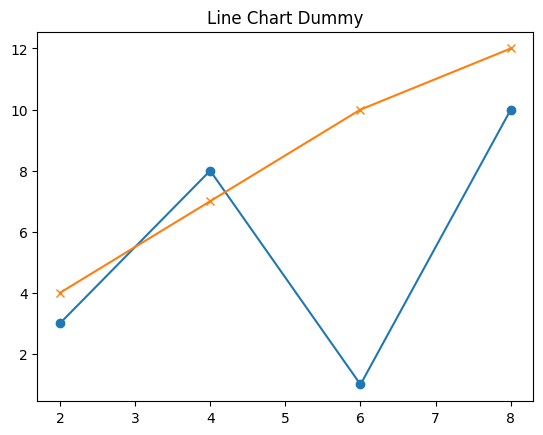

In [7]:
x = np.array([2, 4, 6, 8])
y1 = np.array([3, 8, 1, 10])
y2 = np.array([4, 7, 10, 12])

plt.plot(x, y1, marker='o')
plt.plot(x, y2, marker='x')
plt.title('Line Chart Dummy')
plt.show()


In [8]:
df_iot = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/datatraining.txt')
df_iot['date'] = pd.to_datetime(df_iot['date'])
df_iot.head()


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


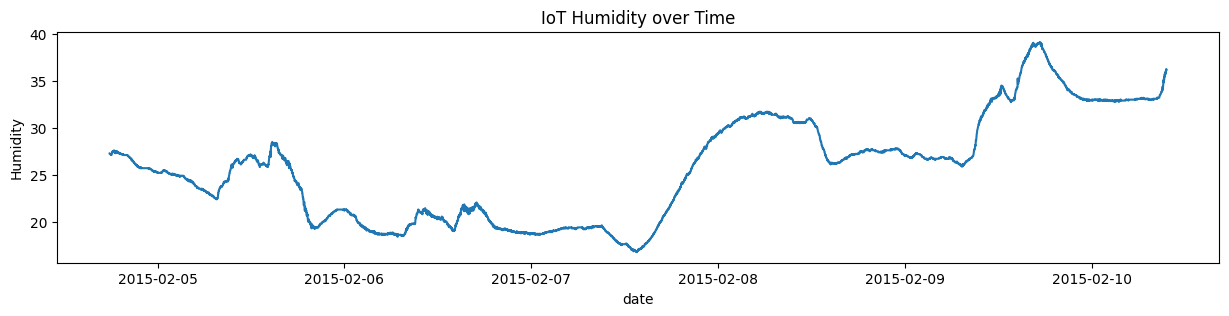

In [9]:
plt.figure(figsize=(15, 3))
plt.plot(df_iot['date'], df_iot['Humidity'])
plt.title('IoT Humidity over Time')
plt.xlabel('date')
plt.ylabel('Humidity')
plt.show()


#### 1.7 Pie Chart


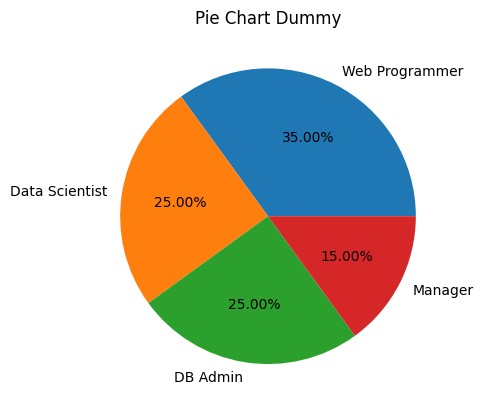

In [10]:
y = np.array([35, 25, 25, 15])
mylabels = ["Web Programmer", "Data Scientist", "DB Admin", "Manager"]

plt.pie(y, labels=mylabels, autopct='%.2f%%')
plt.title('Pie Chart Dummy')
plt.show()


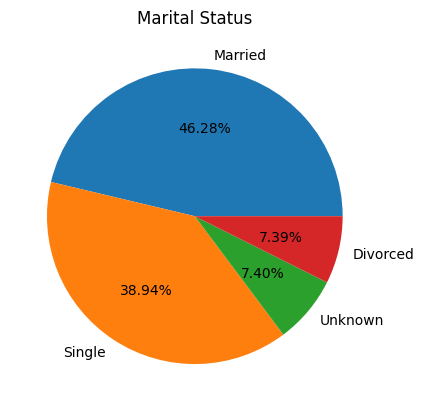

In [11]:
data = df_churning['Marital_Status'].value_counts()
label = data.index

plt.pie(data, labels=label, autopct='%.2f%%')
plt.title('Marital Status')
plt.show()


#### 1.8 Bar Plot


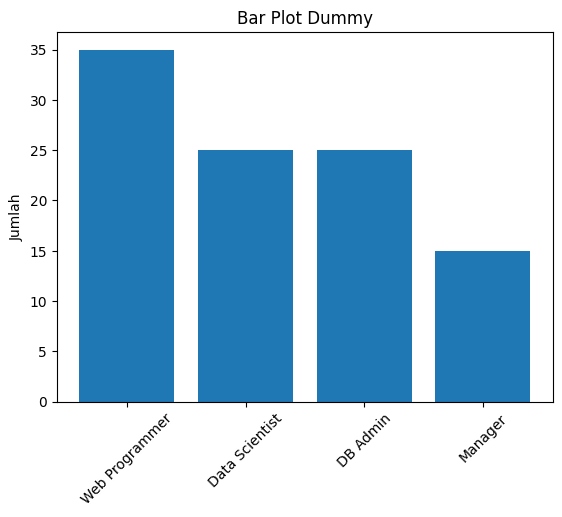

In [12]:
y = np.array([35, 25, 25, 15])
x = ["Web Programmer", "Data Scientist", "DB Admin", "Manager"]

plt.bar(x, y)
plt.xticks(rotation=45)
plt.ylabel('Jumlah')
plt.title('Bar Plot Dummy')
plt.show()


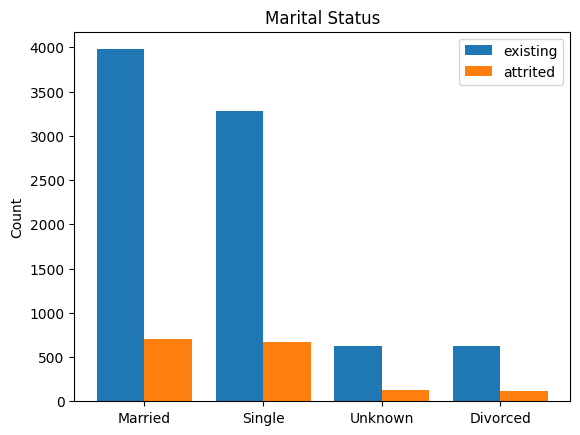

In [13]:
y1 = existing_data['Marital_Status'].value_counts()
y2 = attrited_data['Marital_Status'].value_counts()

x1 = np.arange(len(y1.index))
x2 = np.arange(len(y2.index))
bar_width = 0.4

plt.bar(x1, y1, width=bar_width, label='existing')
plt.bar(x2 + bar_width, y2, width=bar_width, label='attrited')

plt.title('Marital Status')
plt.ylabel('Count')
plt.xticks(x2 + bar_width / 2, labels=df_churning.Marital_Status.unique())
plt.legend()
plt.show()


#### 1.9 Stacked Bar Plot


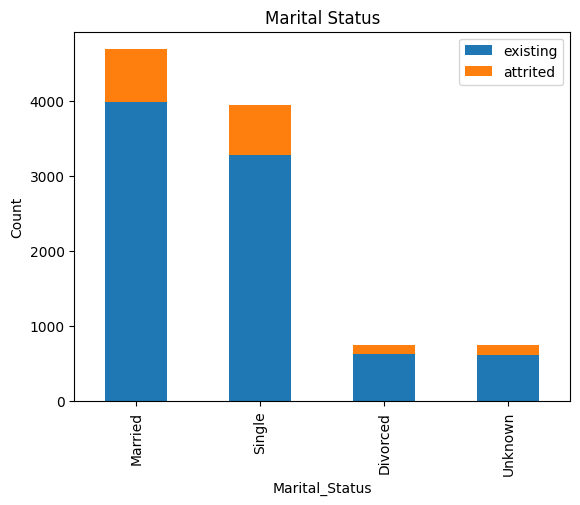

In [14]:
data1 = existing_data['Marital_Status'].value_counts()
data2 = attrited_data['Marital_Status'].value_counts()

df_new = pd.concat([data1, data2], keys=['existing', 'attrited'], axis=1)
df_new.plot(kind='bar', stacked=True)

plt.title('Marital Status')
plt.ylabel('Count')
plt.show()


#### 1.10 Histogram


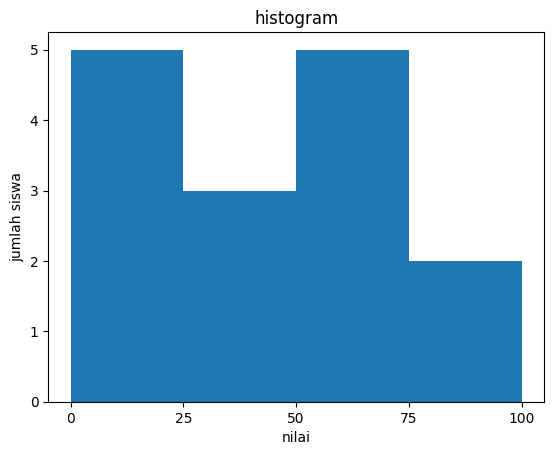

In [15]:
data = np.array([22, 87, 5, 43, 56, 73, 55, 54, 11, 20, 51, 5, 79, 31, 27])
bins = [0, 25, 50, 75, 100]

plt.hist(data, bins=bins)
plt.title('histogram')
plt.xticks([0, 25, 50, 75, 100])
plt.xlabel('nilai')
plt.ylabel('jumlah siswa')
plt.show()


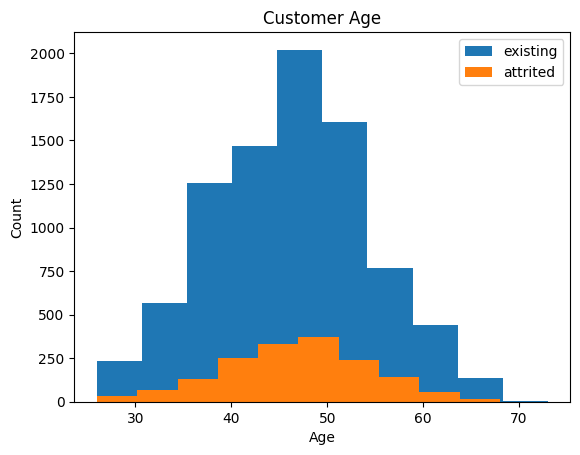

In [16]:
data1 = existing_data['Customer_Age']
data2 = attrited_data['Customer_Age']

plt.hist(data1, label='existing')
plt.hist(data2, label='attrited')

plt.title('Customer Age')
plt.ylabel('Count')
plt.xlabel('Age')
plt.legend()
plt.show()


#### 1.11 Scatter Plot


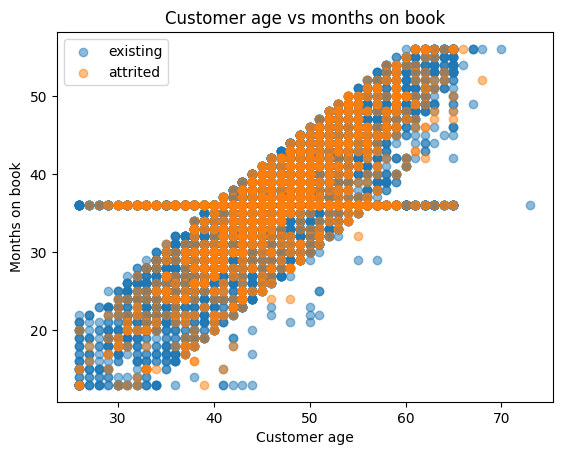

In [17]:
y1 = attrited_data['Months_on_book']
x1 = attrited_data['Customer_Age']
y2 = existing_data['Months_on_book']
x2 = existing_data['Customer_Age']

plt.scatter(x2, y2, label='existing', alpha=0.5)
plt.scatter(x1, y1, label='attrited', alpha=0.5)

plt.title('Customer age vs months on book')
plt.ylabel('Months on book')
plt.xlabel('Customer age')
plt.legend()
plt.show()


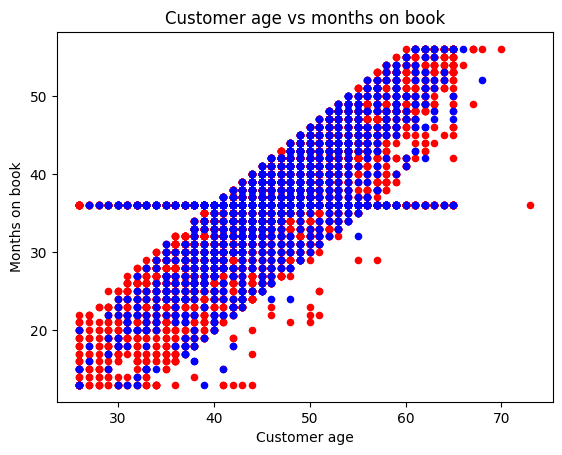

In [18]:
ax = existing_data.plot.scatter(x='Customer_Age', y='Months_on_book', c='red')
attrited_data.plot.scatter(x='Customer_Age', y='Months_on_book', c='blue', ax=ax)

plt.title('Customer age vs months on book')
plt.ylabel('Months on book')
plt.xlabel('Customer age')
plt.show()


#### 1.12 Box Plot


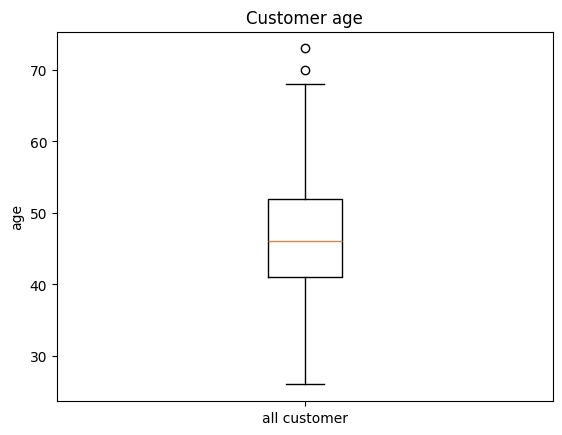

In [19]:
plt.boxplot(df_churning['Customer_Age'])
plt.title('Customer age')
plt.ylabel('age')
plt.xticks([1], labels=['all customer'])
plt.show()


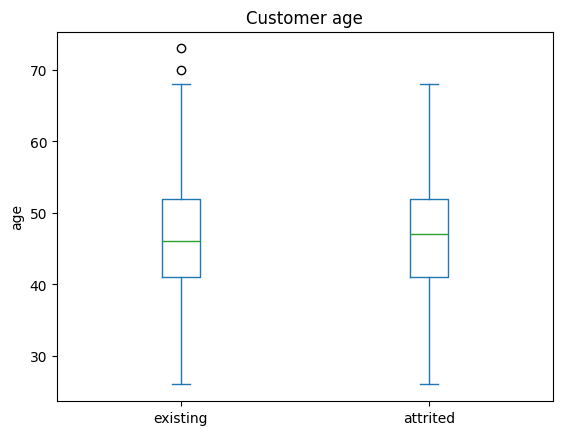

In [20]:
data1 = existing_data['Customer_Age']
data2 = attrited_data['Customer_Age']

df_box = pd.concat([data1, data2], keys=['existing', 'attrited'], axis=1)
df_box.plot.box()

plt.title('Customer age')
plt.ylabel('age')
plt.show()


#### 1.13 Violin Plot


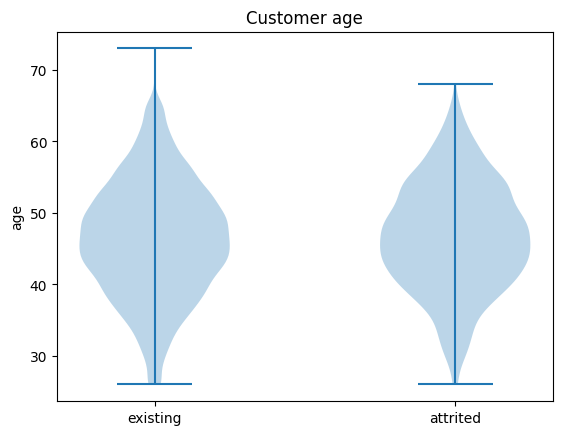

In [21]:
data1 = existing_data['Customer_Age'].values
data2 = attrited_data['Customer_Age'].values

my_dictionary = {'existing': data1, 'attrited': data2}

plt.violinplot(list(my_dictionary.values()))
plt.title('Customer age')
plt.ylabel('age')
plt.xticks([1, 2], labels=list(my_dictionary.keys()))
plt.show()


#### 1.14 Subplot (grid 2x2)


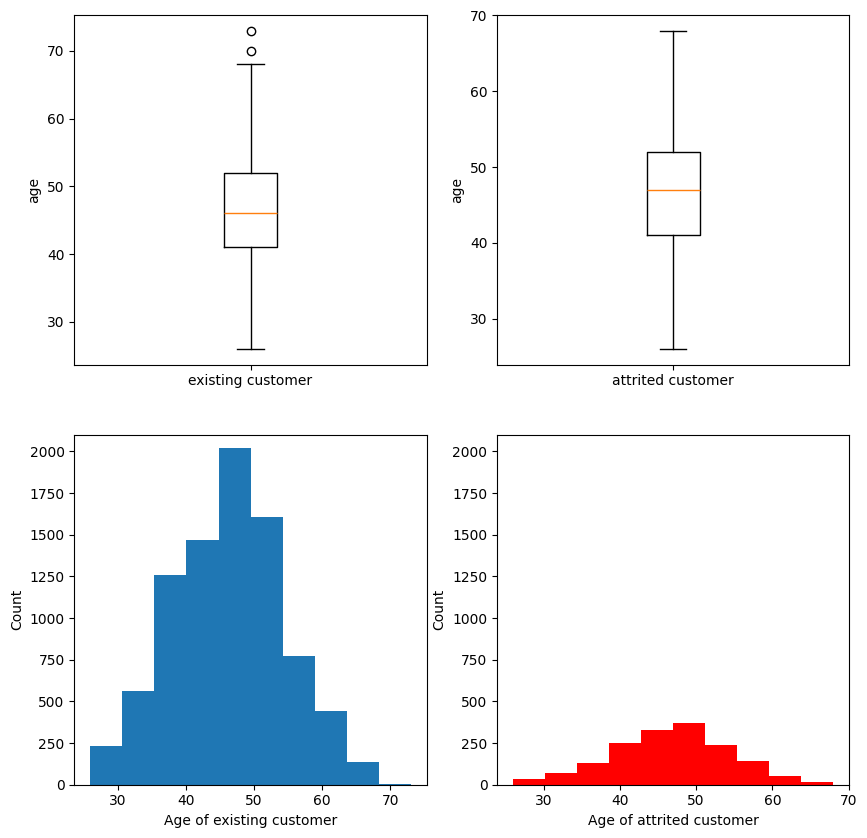

In [22]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.boxplot(existing_data['Customer_Age'])
plt.ylabel('age')
plt.xticks([1], labels=['existing customer'])

plt.subplot(2, 2, 2)
plt.boxplot(attrited_data['Customer_Age'])
plt.ylabel('age')
plt.xticks([1], labels=['attrited customer'])

plt.subplot(2, 2, 3)
existing_data['Customer_Age'].plot.hist()
plt.ylabel('Count')
plt.xlabel('Age of existing customer')
plt.ylim([0, 2100])

plt.subplot(2, 2, 4)
attrited_data['Customer_Age'].plot.hist(color='r')
plt.ylabel('Count')
plt.xlabel('Age of attrited customer')
plt.ylim([0, 2100])

plt.show()


#### 1.15 Annotation


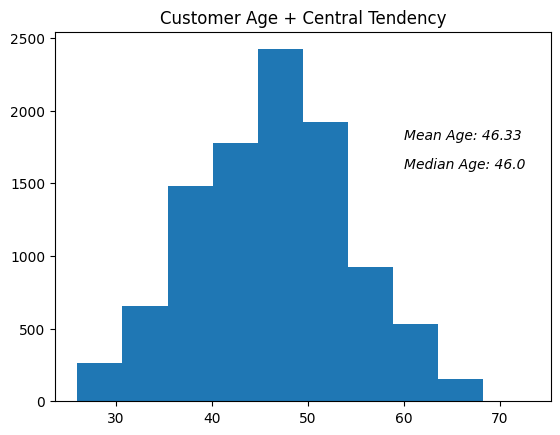

In [23]:
data = df_churning['Customer_Age']
plt.hist(data)
plt.text(60, 1600, 'Median Age: ' + str(round(data.median(), 2)), style='italic', fontsize=10)
plt.text(60, 1800, 'Mean Age: ' + str(round(data.mean(), 2)), style='italic', fontsize=10)
plt.title('Customer Age + Central Tendency')
plt.show()


#### 1.16 Axis (label + ylim)


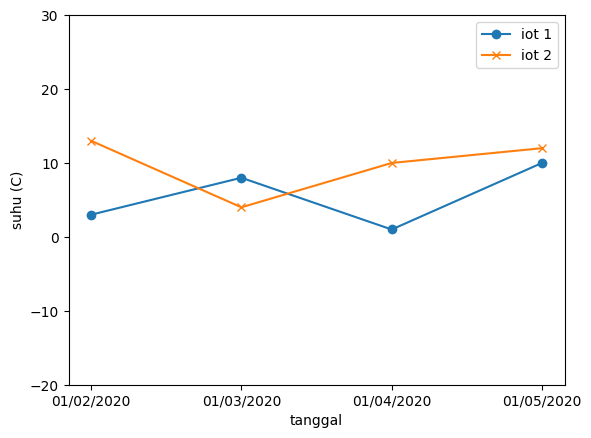

In [24]:
x = np.array(['01/02/2020', '01/03/2020', '01/04/2020', '01/05/2020'])
y1 = np.array([3, 8, 1, 10])
y2 = np.array([13, 4, 10, 12])

plt.plot(x, y1, marker='o', label='iot 1')
plt.plot(x, y2, marker='x', label='iot 2')
plt.legend()

plt.ylabel('suhu (C)', fontsize=10)
plt.xlabel('tanggal', fontsize=10)
plt.ylim([-20, 30])
plt.show()


#### 1.17 Legend


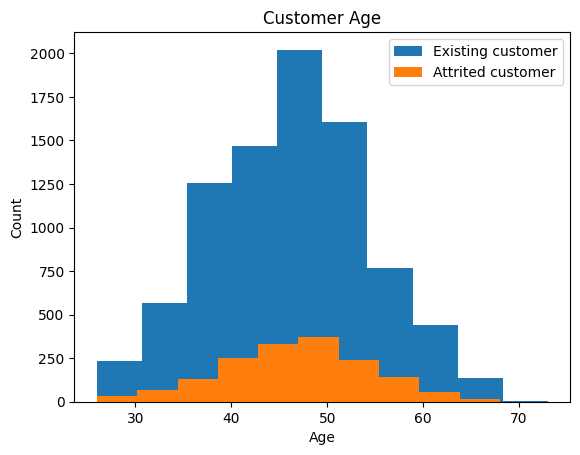

In [25]:
data1 = existing_data['Customer_Age']
data2 = attrited_data['Customer_Age']

plt.hist(data1, label='Existing customer')
plt.hist(data2, label='Attrited customer')

plt.title('Customer Age')
plt.ylabel('Count')
plt.xlabel('Age')
plt.legend()
plt.show()


---
# 2. LANGKAH PERCOBAAN: DATA PREPROCESSING

Pipeline: load → EDA ringkas → missing/duplikat → imputasi → encoding → split → scaling.
Dataset: **Titanic** ([Kaggle](https://www.kaggle.com/datasets/yasserh/titanic-dataset)).


#### 2.1 Impor Pustaka Preprocessing


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


#### 2.2 Load Dataset Titanic


In [27]:
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/train.csv')
print('Shape:', df.shape)


Shape: (891, 12)


#### 2.3 Lima Baris Pertama


In [28]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 2.4 Lima Baris Terakhir


In [29]:
df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


#### 2.5 Bentuk Dataset (`df.shape`)


In [30]:
df.shape  # (baris, kolom)


(891, 12)

#### 2.6 Visualisasi Distribusi


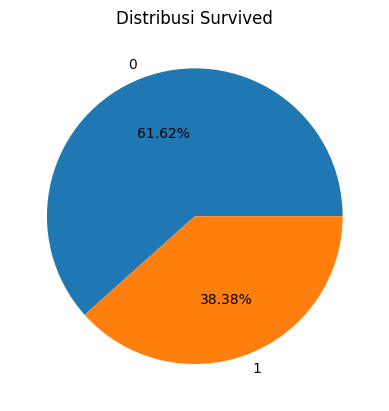

In [31]:
data = df['Survived'].value_counts()
data.plot(kind='pie', autopct='%.2f%%')
plt.title('Distribusi Survived')
plt.ylabel('')
plt.show()


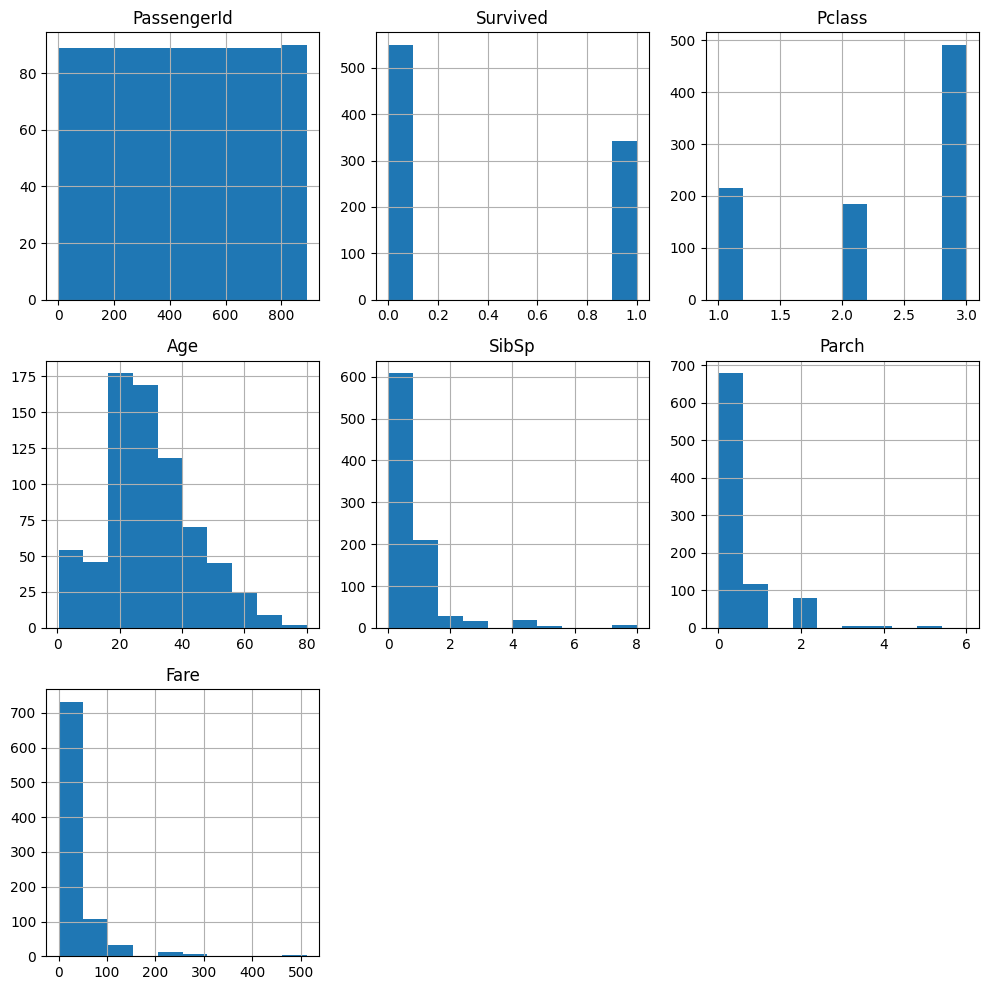

In [32]:
df.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()


#### 2.7 Korelasi Antar Variabel Numerik


In [33]:
df.corr(numeric_only=True)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Catatan korelasi Titanic:** `Pclass` vs `Survived` negatif (~-0.34) — kelas lebih rendah, peluang selamat lebih kecil. `Fare` vs `Survived` positif (~0.26) — tiket mahal cenderung selamat. `Age`, `SibSp`, `Parch` lemah terhadap target.


#### 2.8 Descriptive Statistics


In [34]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### 2.9 Missing Values dan Duplikat


In [35]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [36]:
print('Duplikat:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape setelah drop_duplicates:', df.shape)


Duplikat: 0
Shape setelah drop_duplicates: (891, 12)


#### 2.10 Imputasi
Numerik (`Age`) → median. Kategorikal (`Cabin`, `Embarked`) → modus.


In [37]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].value_counts().index[0])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].value_counts().index[0])
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#### 2.11 Cek Atribut Kategorikal


In [38]:
df_X = df.drop(['PassengerId', 'Name', 'Survived', 'Cabin', 'Ticket'], axis=1)
df_y = df['Survived']

cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)


Index(['Sex', 'Embarked'], dtype='object')


#### 2.12 One-Hot Encoding
`pd.get_dummies(..., drop_first=True)` hindari dummy trap. Alternatif: `sklearn.OneHotEncoder`.


In [39]:
df_onehot = pd.get_dummies(df_X, columns=['Sex', 'Embarked'], drop_first=True)
df_onehot.head()


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [40]:
ohe = OneHotEncoder(sparse_output=False)
ohe.fit(df_X[['Sex', 'Embarked']])
df_ohe = ohe.transform(df_X[['Sex', 'Embarked']])
df_ohe


array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0.]])

#### 2.13 Label Encoding


In [41]:
df_X_le = df_X.copy()
cats = df_X_le.select_dtypes(include=['object', 'bool']).columns
cat_features = list(cats.values)
cat_en = LabelEncoder()

for i in cat_features:
    df_X_le[i] = cat_en.fit_transform(df_X_le[i])

df_X = df_X_le
df_X


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,2
887,1,0,19.0,0,0,30.0000,2
888,3,0,28.0,1,2,23.4500,2
889,1,1,26.0,0,0,30.0000,0


In [42]:
le = LabelEncoder()
df_y = le.fit_transform(df_y)
df_y


array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,

#### 2.14 Korelasi setelah Encoding


In [43]:
df_y_new = pd.DataFrame(df_y, columns=['Survived'])
df_gabung = pd.concat([df_X.reset_index(drop=True), df_y_new], axis=1)
df_gabung.corr()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
Pclass,1.000000,0.131900,-0.339898,0.083081,0.018443,-0.549500,0.162098,-0.338481
Sex,0.131900,1.000000,0.081163,-0.114631,-0.245489,-0.182333,0.108262,-0.543351
Age,-0.339898,0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.018754,-0.064910
SibSp,0.083081,-0.114631,-0.233296,1.000000,0.414838,0.159651,0.068230,-0.035322
Parch,0.018443,-0.245489,-0.172482,0.414838,1.000000,0.216225,0.039798,0.081629
Fare,-0.549500,-0.182333,0.096688,0.159651,0.216225,1.000000,-0.224719,0.257307
Embarked,0.162098,0.108262,-0.018754,0.068230,0.039798,-0.224719,1.000000,-0.167675
Survived,-0.338481,-0.543351,-0.064910,-0.035322,0.081629,0.257307,-0.167675,1.000000


#### 2.15 Train-Test Split (70:30)


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.3, random_state=42
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
X_train


X_train: (623, 7) | X_test: (268, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
445,1,1,4.0,0,2,81.8583,2
650,3,1,28.0,0,0,7.8958,2
172,3,0,1.0,1,1,11.1333,2
450,2,1,36.0,1,2,27.7500,2
314,2,1,43.0,1,1,26.2500,2
...,...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500,2
270,1,1,28.0,0,0,31.0000,2
860,3,1,41.0,2,0,14.1083,2
435,1,0,14.0,1,2,120.0000,2


#### 2.16 Scaling
Fit scaler **hanya di train**, transform train + test. Dua demo terpisah: `StandardScaler` lalu `MinMaxScaler` (pakai copy biar gak ketimpa).


In [45]:
scaler_std = StandardScaler()
scaler_std.fit(X_train)

X_train_std = scaler_std.transform(X_train)
X_test_std = scaler_std.transform(X_test)
X_train_std


array([[-1.63788124,  0.72077194, -1.91971935, ...,  1.99885349,
         0.98099823,  0.57000481],
       [ 0.80326712,  0.72077194, -0.0772525 , ..., -0.47932706,
        -0.46963364,  0.57000481],
       [ 0.80326712, -1.38740139, -2.15002771, ...,  0.75976322,
        -0.40613632,  0.57000481],
       ...,
       [ 0.80326712,  0.72077194,  0.92075038, ..., -0.47932706,
        -0.34778742,  0.57000481],
       [-1.63788124, -1.38740139, -1.15202483, ...,  1.99885349,
         1.72907416,  0.57000481],
       [-1.63788124,  0.72077194, -0.61463866, ...,  0.75976322,
         0.8913508 ,  0.57000481]])

In [46]:
scaler_mm = MinMaxScaler()
scaler_mm.fit(X_train)

X_train_mm = scaler_mm.transform(X_train)
X_test_mm = scaler_mm.transform(X_test)
X_train_mm


array([[0.        , 1.        , 0.04498618, ..., 0.33333333, 0.15977676,
        1.        ],
       [1.        , 1.        , 0.34656949, ..., 0.        , 0.01541158,
        1.        ],
       [1.        , 0.        , 0.00728826, ..., 0.16666667, 0.02173075,
        1.        ],
       ...,
       [1.        , 1.        , 0.50992712, ..., 0.        , 0.02753757,
        1.        ],
       [0.        , 0.        , 0.17064589, ..., 0.33333333, 0.2342244 ,
        1.        ],
       [0.        , 1.        , 0.25860769, ..., 0.16666667, 0.15085515,
        1.        ]])

---
# 3. TUGAS & ANALISIS (BAB 2.5)

Dua blok: **EDA** (Bank Churners) dan **Data Preprocessing** (Bengaluru House Price).


## A. Exploratory Data Analysis
Dataset: [Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)


### A.1 Baca Dataset pakai DataFrame


In [47]:
df_tugas_eda = pd.read_csv(
    'https://raw.githubusercontent.com/ganjar87/data_science_practice/main/BankChurners.csv'
)
print('Shape :', df_tugas_eda.shape)
print('Dtypes:')
print(df_tugas_eda.dtypes)
df_tugas_eda.head()


Shape : (10127, 21)
Dtypes:
CLIENTNUM                     int64
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### A.2 Tujuan Penggunaan Dataset

Dataset **BankChurners** dipakai untuk **prediksi churn** nasabah kartu kredit: apakah nasabah tetap aktif (`Existing Customer`) atau berhenti (`Attrited Customer`).

Tujuan praktis:
1. Identifikasi pola nasabah yang berisiko churn (transaksi, limit, inaktivitas, kontak).
2. Jadi bahan **supervised classification** — label sudah ada di `Attrition_Flag`.
3. Support keputusan retensi (penawaran, limit, engagement) sebelum nasabah benar-benar pergi.

Dua kolom terakhir (`Naive_Bayes_...`) adalah output classifier bawaan dataset, **bukan fitur mentah**. Drop sebelum modeling — kalau dipakai, target bocor (data leakage).


### A.3 Input vs Output (Class/Label)

| Peran | Atribut |
| --- | --- |
| **Output / label** | `Attrition_Flag` |
| **Dibuang** | `CLIENTNUM` (ID, bukan sinyal), 2 kolom `Naive_Bayes_*` (leakage) |
| **Input / fitur** | Semua kolom sisanya (demografi, relasi bank, kredit, transaksi) |


In [48]:
nb_cols = [c for c in df_tugas_eda.columns if 'Naive_Bayes' in c]
drop_cols = ['CLIENTNUM'] + nb_cols

y_col = 'Attrition_Flag'
X_cols = [c for c in df_tugas_eda.columns if c not in drop_cols + [y_col]]

print('Label  :', y_col)
print('Drop   :', drop_cols)
print('Fitur  :', X_cols)
print('\nDistribusi label:')
print(df_tugas_eda[y_col].value_counts())
print(df_tugas_eda[y_col].value_counts(normalize=True).round(4))


Label  : Attrition_Flag
Drop   : ['CLIENTNUM']
Fitur  : ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Distribusi label:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    0.8393
Attrited Customer    0.1607
Name: proportion, dtype: float64


### A.4 Penjelasan Singkat tiap Atribut


In [49]:
attr_desc = {
    'CLIENTNUM': 'ID unik nasabah (bukan fitur prediktif)',
    'Attrition_Flag': 'Label: Existing Customer vs Attrited Customer',
    'Customer_Age': 'Usia nasabah (tahun)',
    'Gender': 'Jenis kelamin (M/F)',
    'Dependent_count': 'Jumlah tanggungan',
    'Education_Level': 'Jenjang pendidikan',
    'Marital_Status': 'Status pernikahan',
    'Income_Category': 'Kelompok pendapatan tahunan',
    'Card_Category': 'Tipe kartu (Blue/Silver/Gold/Platinum)',
    'Months_on_book': 'Lama menjadi nasabah (bulan)',
    'Total_Relationship_Count': 'Jumlah produk yang dipegang',
    'Months_Inactive_12_mon': 'Bulan tidak aktif dalam 12 bulan terakhir',
    'Contacts_Count_12_mon': 'Jumlah kontak ke bank dalam 12 bulan terakhir',
    'Credit_Limit': 'Limit kredit',
    'Total_Revolving_Bal': 'Saldo revolving',
    'Avg_Open_To_Buy': 'Sisa limit yang bisa dipakai',
    'Total_Amt_Chng_Q4_Q1': 'Rasio perubahan nominal transaksi Q4/Q1',
    'Total_Trans_Amt': 'Total nominal transaksi',
    'Total_Trans_Ct': 'Total jumlah transaksi',
    'Total_Ct_Chng_Q4_Q1': 'Rasio perubahan jumlah transaksi Q4/Q1',
    'Avg_Utilization_Ratio': 'Rasio utilisasi kredit (saldo/limit)',
}

rows = []
for col in df_tugas_eda.columns:
    desc = attr_desc.get(col, 'Output Naive Bayes bawaan dataset (drop, leakage)')
    nunique = df_tugas_eda[col].nunique(dropna=False)
    rows.append({
        'atribut': col,
        'dtype': str(df_tugas_eda[col].dtype),
        'nunique': nunique,
        'penjelasan': desc,
    })

pd.DataFrame(rows)


,atribut,dtype,nunique,penjelasan
0,CLIENTNUM,int64,10127,ID unik nasabah (bukan fitur prediktif)
1,Attrition_Flag,object,2,Label: Existing Customer vs Attrited Customer
2,Customer_Age,int64,45,Usia nasabah (tahun)
3,Gender,object,2,Jenis kelamin (M/F)
4,Dependent_count,int64,6,Jumlah tanggungan
5,Education_Level,object,7,Jenjang pendidikan
6,Marital_Status,object,4,Status pernikahan
7,Income_Category,object,6,Kelompok pendapatan tahunan
8,Card_Category,object,4,Tipe kartu (Blue/Silver/Gold/Platinum)
9,Months_on_book,int64,44,Lama menjadi nasabah (bulan)


---
## B. Data Preprocessing
Dataset: [Bengaluru House Price Data](https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data)


### B.1 Baca Dataset pakai DataFrame


In [50]:
URL_BENGALURU = 'https://raw.githubusercontent.com/dphi-official/Datasets/master/Bengaluru_House_Data.csv'
df_house = pd.read_csv(URL_BENGALURU)

print('Shape :', df_house.shape)
print('Kolom :', list(df_house.columns))
print('\nDtypes:')
print(df_house.dtypes)
df_house.head()


Shape : (13320, 9)
Kolom : ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

Dtypes:
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


**Kolom dataset:** `area_type`, `availability`, `location`, `size`, `society`, `total_sqft`, `bath`, `balcony`, `price` (target, satuan lakh INR).
`total_sqft` bertipe object (ada range seperti `2100 - 2850` dan satuan). Parse dulu sebelum histogram/korelasi numerik.


In [51]:
def parse_sqft(val):
    if pd.isna(val):
        return np.nan
    text = str(val).strip()
    if '-' in text:
        parts = text.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    num = ''
    for ch in text:
        if ch.isdigit() or ch == '.':
            num += ch
        elif num:
            break
    try:
        return float(num) if num else np.nan
    except ValueError:
        return np.nan


def parse_bhk(val):
    if pd.isna(val):
        return np.nan
    token = str(val).split()[0]
    try:
        return float(token)
    except ValueError:
        return np.nan


df_house['total_sqft_num'] = df_house['total_sqft'].apply(parse_sqft)
df_house['bhk'] = df_house['size'].apply(parse_bhk)
print(df_house[['total_sqft', 'total_sqft_num', 'size', 'bhk']].head(8))


  total_sqft  total_sqft_num       size  bhk
0       1056          1056.0      2 BHK  2.0
1       2600          2600.0  4 Bedroom  4.0
2       1440          1440.0      3 BHK  3.0
3       1521          1521.0      3 BHK  3.0
4       1200          1200.0      2 BHK  2.0
5       1170          1170.0      2 BHK  2.0
6       2732          2732.0      4 BHK  4.0
7       3300          3300.0      4 BHK  4.0


### B.2 Histogram Variabel Numerik + Pola Distribusi


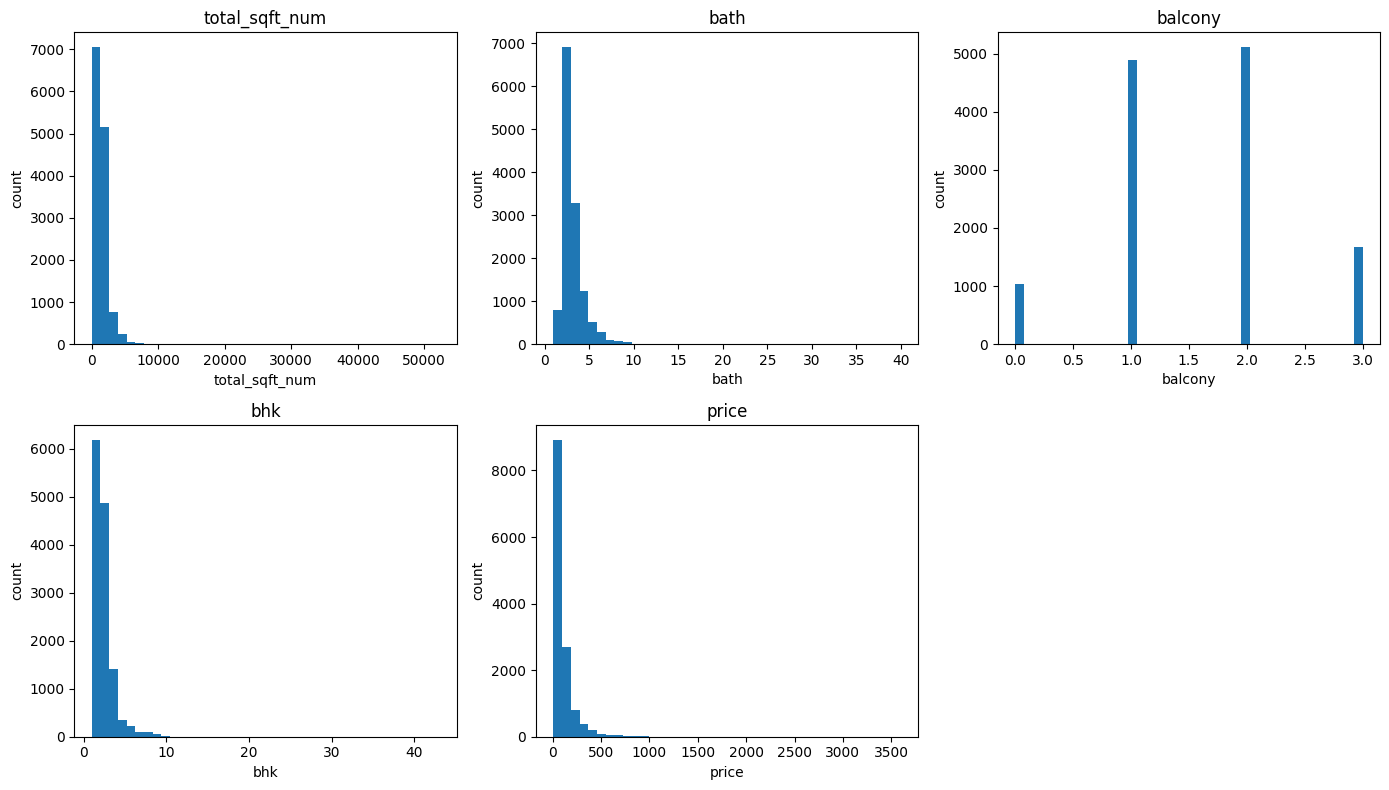

total_sqft_num    15.201668
bath               4.227697
balcony            0.005857
bhk                4.822009
price              8.064469
dtype: float64


In [52]:
num_cols = ['total_sqft_num', 'bath', 'balcony', 'bhk', 'price']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    axes[i].hist(df_house[col].dropna(), bins=40)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print(df_house[num_cols].skew(numeric_only=True))


**Analisis distribusi:**
1. **`price`** — right-skewed. Mayoritas rumah di harga menengah-bawah, ekor panjang ke harga sangat mahal (outlier mewah).
2. **`total_sqft_num`** — sama, skew kanan. Ada nilai ekstrem (salah parse satuan / rumah sangat luas).
3. **`bath` & `bhk`** — diskrit, puncak di 2–3. Ekor ke jumlah kamar mandi/BHK besar.
4. **`balcony`** — puncak di 1–2, missing cukup banyak (terlihat dari count histogram).

Implikasi: mean sensitif outlier → imputasi numerik pakai **median**. Scaling wajib sebelum model berbasis jarak. Outlier bisa di-cap/filter di tahap lanjutan (tidak dipaksa di soal ini).


### B.3 Korelasi Antar Variabel + Hubungan yang Terlihat


,total_sqft_num,bath,balcony,bhk,price
total_sqft_num,1.000000,0.391148,0.149555,0.347107,0.573396
bath,0.391148,1.000000,0.204201,0.898408,0.456345
balcony,0.149555,0.204201,1.000000,0.187291,0.120355
bhk,0.347107,0.898408,0.187291,1.000000,0.398292
price,0.573396,0.456345,0.120355,0.398292,1.000000


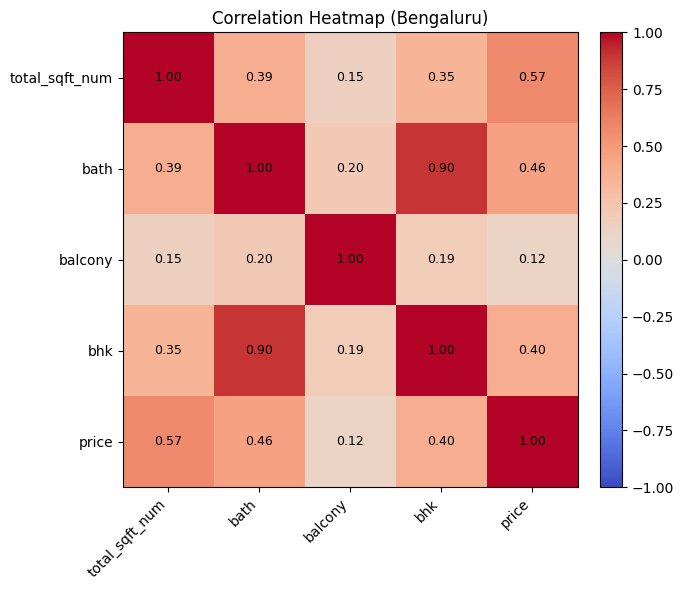

In [53]:
corr_house = df_house[num_cols].corr(numeric_only=True)
display(corr_house)

plt.figure(figsize=(7, 6))
im = plt.imshow(corr_house, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_house.columns)), corr_house.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_house.columns)), corr_house.columns)
plt.title('Correlation Heatmap (Bengaluru)')
for (r, c), val in np.ndenumerate(corr_house.values):
    plt.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Analisis korelasi:**
- `bath`–`bhk` biasanya **kuat positif** — lebih banyak kamar, lebih banyak kamar mandi.
- `total_sqft_num` vs `price` **positif** — luas naik, harga naik (sinyal prediktif utama).
- `bath`/`bhk` vs `price` positif sedang — ukuran hunian ikut dorong harga.
- `balcony` vs `price` **lemah** — balkon bukan driver harga utama.

Multikolinearitas `bath`–`bhk` ada. Untuk model linear, pilih salah satu atau biarkan (tree-based lebih tahan).


### B.4 Descriptive Statistics, Missing Value, Duplikasi


In [54]:
print('=== describe numerik ===')
display(df_house.describe(include='number'))

print('\n=== describe kategorikal ===')
display(df_house.describe(include='object'))

print('\n=== missing values ===')
miss = df_house.isnull().sum()
miss_pct = (miss / len(df_house) * 100).round(2)
display(pd.DataFrame({'missing': miss, 'pct': miss_pct}))

n_dup = int(df_house.duplicated().sum())
print('Duplikat baris:', n_dup)


=== describe numerik ===


,bath,balcony,price,total_sqft_num,bhk
count,13247.000000,12711.000000,13320.000000,13320.000000,13304.000000
mean,2.692610,1.584376,112.565627,1555.971707,2.803743
std,1.341458,0.817263,148.971674,1238.902448,1.294974
min,1.000000,0.000000,8.000000,1.000000,1.000000
25%,2.000000,1.000000,50.000000,1100.000000,2.000000
50%,2.000000,2.000000,72.000000,1275.000000,3.000000
75%,3.000000,2.000000,120.000000,1679.250000,3.000000
max,40.000000,3.000000,3600.000000,52272.000000,43.000000



=== describe kategorikal ===


,area_type,availability,location,size,society,total_sqft
count,13320,13320,13319,13304,7818,13320
unique,4,81,1305,31,2688,2117
top,Super built-up Area,Ready To Move,Whitefield,2 BHK,GrrvaGr,1200
freq,8790,10581,540,5199,80,843



=== missing values ===


,missing,pct
area_type,0,0.00
availability,0,0.00
location,1,0.01
size,16,0.12
society,5502,41.31
total_sqft,0,0.00
bath,73,0.55
balcony,609,4.57
price,0,0.00
total_sqft_num,0,0.00


Duplikat baris: 529


**Tindakan jika missing / duplikat ketemu:**

| Masalah | Tindakan |
| --- | --- |
| Duplikat baris | `drop_duplicates()` — baris identik gak nambah info, malah nimbang ganda |
| `society` missing besar (~41%) | **Drop kolom**. Imputasi modus bikin mayoritas palsu, kardinalitas tinggi |
| `balcony` missing | Imputasi **median** (numerik diskrit, skew) |
| `bath`, `size`/`bhk`, `location` missing kecil | Drop baris (proporsi kecil) atau modus/median |
| `total_sqft` gagal parse | Drop baris yang `NaN` setelah parse |

Jangan impute dulu baru drop duplikat — urutan: drop duplikat → handle missing.


In [55]:
df_pp = df_house.copy()
print('Sebelum:', df_pp.shape, '| dup:', int(df_pp.duplicated().sum()))

df_pp = df_pp.drop_duplicates()
df_pp = df_pp.drop(columns=['society'])
df_pp = df_pp.dropna(subset=['location', 'size', 'bath', 'bhk', 'total_sqft_num'])
df_pp['balcony'] = df_pp['balcony'].fillna(df_pp['balcony'].median())

print('Sesudah :', df_pp.shape)
print('Missing sisa:')
print(df_pp.isnull().sum())


Sebelum: (13320, 11) | dup: 529
Sesudah : (12717, 10)
Missing sisa:
area_type         0
availability      0
location          0
size              0
total_sqft        0
bath              0
balcony           0
price             0
total_sqft_num    0
bhk               0
dtype: int64


### B.5 Encoding, Train-Test Split 80:20, Scaling


In [56]:
df_model = df_pp.drop(columns=['availability', 'size', 'total_sqft']).copy()

y_house = df_model['price']
X_house = df_model.drop(columns=['price'])

print('Fitur mentah:')
print(X_house.dtypes)
print('\nKardinalitas kategorikal:')
for c in X_house.select_dtypes(include='object').columns:
    print(f'  {c}: {X_house[c].nunique()} unique')


Fitur mentah:
area_type          object
location           object
bath              float64
balcony           float64
total_sqft_num    float64
bhk               float64
dtype: object

Kardinalitas kategorikal:
  area_type: 4 unique
  location: 1304 unique


In [57]:
# One-hot: area_type (kardinalitas rendah)
X_ohe = pd.get_dummies(X_house, columns=['area_type'], drop_first=True)

# Label encode: location (kardinalitas tinggi — one-hot meledak)
le_loc = LabelEncoder()
X_ohe['location'] = le_loc.fit_transform(X_ohe['location'])

print('Shape setelah encoding:', X_ohe.shape)
X_ohe.head()


Shape setelah encoding: (12717, 8)


,location,bath,balcony,total_sqft_num,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,419,2.0,1.0,1056.0,2.0,False,False,True
1,317,5.0,3.0,2600.0,4.0,False,True,False
2,1178,2.0,3.0,1440.0,3.0,False,False,False
3,756,3.0,1.0,1521.0,3.0,False,False,True
4,715,2.0,1.0,1200.0,2.0,False,False,True


In [58]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_ohe, y_house, test_size=0.2, random_state=42
)
print('Train:', X_train_h.shape, '| Test:', X_test_h.shape)

num_scale_cols = ['total_sqft_num', 'bath', 'balcony', 'bhk']

scaler_house = StandardScaler()
X_train_scaled = X_train_h.copy()
X_test_scaled = X_test_h.copy()
X_train_scaled[num_scale_cols] = scaler_house.fit_transform(X_train_h[num_scale_cols])
X_test_scaled[num_scale_cols] = scaler_house.transform(X_test_h[num_scale_cols])

print('\nTrain numerik setelah StandardScaler (mean ~0, std ~1):')
print(X_train_scaled[num_scale_cols].describe().round(3).loc[['mean', 'std']])
X_train_scaled.head()


Train: (10173, 8) | Test: (2544, 8)

Train numerik setelah StandardScaler (mean ~0, std ~1):
      total_sqft_num  bath  balcony  bhk
mean             0.0   0.0     -0.0 -0.0
std              1.0   1.0      1.0  1.0


,location,bath,balcony,total_sqft_num,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
8040,1038,-0.524952,-0.744362,-0.009039,0.135110,False,False,True
5774,947,3.122321,1.726642,-0.748629,3.167599,False,False,False
8025,1059,0.933957,0.491140,1.166521,0.893232,False,False,True
12109,654,0.933957,0.491140,-0.631852,0.893232,False,True,False
4379,1215,3.122321,1.726642,-0.281519,3.925721,False,True,False


In [59]:
scaler_mm_h = MinMaxScaler()
X_train_mm_h = X_train_h.copy()
X_test_mm_h = X_test_h.copy()
X_train_mm_h[num_scale_cols] = scaler_mm_h.fit_transform(X_train_h[num_scale_cols])
X_test_mm_h[num_scale_cols] = scaler_mm_h.transform(X_test_h[num_scale_cols])

print('MinMax train (min ~0, max ~1):')
print(X_train_mm_h[num_scale_cols].describe().round(3).loc[['min', 'max']])


MinMax train (min ~0, max ~1):
     total_sqft_num  bath  balcony  bhk
min             0.0   0.0      0.0  0.0
max             1.0   1.0      1.0  1.0


**Alasan tiap teknik:**

1. **One-hot (`area_type`)** — kategori nominal, jumlah kelas kecil (Super built-up / Plot / Built-up / Carpet). One-hot gak ngasih urutan palsu. `drop_first=True` hindari dummy trap.
2. **Label encoding (`location`)** — ratusan lokasi. One-hot bikin ratusan kolom sparse. Label encode kompromis: 1 kolom integer. Catatan: tree-based oke; model linear bisa salah baca angka sebagai ordinal. Alternatif upgrade: target encoding / frequency encoding.
3. **Train-test split 80:20** — hold-out. Train buat fit transformer + model, test buat evaluasi. Split **sebelum** scaling biar statistik test gak bocor ke scaler.
4. **StandardScaler (dipilih utama)** — z-score, tahan-ish ke rentang liar dibanding min-max. Cocok KNN/SVM/linear. Fit di train only.
5. **MinMaxScaler (demo)** — paksa ke [0, 1]. Sensitif outlier (`price`/`sqft` ekstrem). Dipakai kalau algoritma butuh bound ketat (NN dengan sigmoid, dsb.).

`availability` di-drop: campuran tanggal + `Ready To Move`, noise tinggi untuk soal ini. `size` diganti `bhk` numerik.
